<a href="https://colab.research.google.com/github/alyona-vishnoi/learning-RL/blob/main/OPE.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Assume we have logs from an old system. We would then want to know if a new policy would be better - without deploying it. That's where OPE comes in.

We will build
- A simulator (fake PlayStation environment)
- A behavior policy (old system) that generates logs
- An evaluation policy (new system) you want to test
- Three estimators: DM, IPS, Doubly Robust
- A ground truth check (since you control the sim, you can verify)

In [1]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
import random

#  STEP 1: Define the Simulator

It's essentially a lookup table that answers two questions: "what reward do I get?" and "what state am I in next?"

In [2]:
class NBASimulator:
    def __init__(self):
        self.states  = ['active', 'lapsed_7d', 'lapsed_30d']
        self.actions = ['email', 'banner', 'push']

        # reward table
        self.rewards = {
            ('active', 'email'):  2,
            ('active', 'banner'): 3,
            ('active', 'push'):   1,
            ('lapsed_7d', 'email'):  3,
            ('lapsed_7d', 'banner'): 2,
            ('lapsed_7d', 'push'):   1,
            ('lapsed_30d', 'email'):  2,
            ('lapsed_30d', 'banner'): 1,
            ('lapsed_30d', 'push'):   3,
        }

        # transition table — probability of next state
        self.transitions = {
            ('active', 'email'):  {'active': 0.7, 'lapsed_7d': 0.2, 'lapsed_30d': 0.1},
            ('active', 'banner'): {'active': 0.8, 'lapsed_7d': 0.15,'lapsed_30d': 0.05},
            ('active', 'push'):   {'active': 0.6, 'lapsed_7d': 0.3, 'lapsed_30d': 0.1},
            ('lapsed_7d', 'email'):  {'active': 0.6, 'lapsed_7d': 0.3, 'lapsed_30d': 0.1},
            ('lapsed_7d', 'banner'): {'active': 0.3, 'lapsed_7d': 0.5, 'lapsed_30d': 0.2},
            ('lapsed_7d', 'push'):   {'active': 0.2, 'lapsed_7d': 0.4, 'lapsed_30d': 0.4},
            ('lapsed_30d', 'email'):  {'active': 0.2, 'lapsed_7d': 0.3, 'lapsed_30d': 0.5},
            ('lapsed_30d', 'banner'): {'active': 0.1, 'lapsed_7d': 0.2, 'lapsed_30d': 0.7},
            ('lapsed_30d', 'push'):   {'active': 0.4, 'lapsed_7d': 0.3, 'lapsed_30d': 0.3},
        }

    def reset(self):
        # gives a starting state
        # just picks randomly from [active, lapsed_7d, lapsed_30d]
        return random.choice(self.states)

    def step(self, state, action):
        # get reward, add small noise so it's not perfectly deterministic
        reward = self.rewards[(state, action)] + np.random.normal(0, 0.1)
        # Real user behavior isn't deterministic
        # eg- the same email sent to the same user type will get different CTR each time.
        # Without noise, a reward model could get a perfect score by memorizing the table, which isn't useful.

        # sample next state from transition probabilities
        probs = self.transitions[(state, action)]
        next_state = random.choices(
            list(probs.keys()),
            weights=list(probs.values())
        )[0]

        return next_state, reward

env = NBASimulator()
print("simulator ready")

simulator ready


The simulator is used in TWO separate places — once to generate the logs (run by the behavior policy), and once at the end to compute the true value (run by the eval policy).

# STEP 2: Define the Old Behavior Policy

In [22]:
def behavior_policy(state):
    """
    Old system — mostly sends email, some banner, rarely push.
    Same probabilities regardless of state (no personalization).
    Returns: action, propensity (probability assigned to that action)
    """
    # probs = {'email': 0.6, 'banner': 0.3, 'push': 0.1}
    probs = {'email': 0.02, 'banner': 0.02, 'push': 0.96}
    # EG- send push 96% of the time

    action = random.choices(
        list(probs.keys()),
        weights=list(probs.values())
    )[0]
    propensity = probs[action]

    return action, propensity
    # where propensity = what probability did we assign to that specific action
    # Later in IPS, for every logged row we need to know
    # "how likely was the old system to have taken this action?"

# sanity check
action, prop = behavior_policy('lapsed_30d')
print(f"action: {action}, propensity: {prop}")

action: push, propensity: 0.96


The behavior policy feeds directly into generate_logs — every call to behavior_policy() produces one row in the dataset. the propensity it returns is stored in that row and used later by IPS and DR.

# STEP 3: Define the New Evaluation Policy
It never ran, we want to know how good it would have been.
Defined by hand here (no training), but it could be a CQL-trained neural net.

It returns a full probability distribution, not just one action. This matters for two reasons:

- DM needs to compute expected reward across all actions
- PS needs pi_e(a|s) for the specific action that was logged — look it up from this dict using the logged action as the key

In [23]:
def eval_policy(state):
    """
    New policy — personalized per state.
    Returns: full probability distribution over actions
    """
    if state == 'active':
        return {'email': 0.2, 'banner': 0.7, 'push': 0.1}
    elif state == 'lapsed_7d':
        return {'email': 0.7, 'banner': 0.2, 'push': 0.1}
    else:  # lapsed_30d
        return {'email': 0.1, 'banner': 0.1, 'push': 0.8}

# Probabilities sum to 1

The eval policy is passed as a function argument into all three estimators (DM, IPS, DR). each estimator uses it differently — DM uses the full distribution, IPS uses the probability for one specific action.

# STEP 4: Generate Logged Data

Run the behavior policy through the simulator for 10,000 steps. Every step produces one row in the log. Each row is one decision the old system made and what happened.

In [24]:
def generate_logs(env, n_steps=10000):
    logs = []
    state = env.reset()

    for _ in range(n_steps):
        action, propensity = behavior_policy(state)
        next_state, reward = env.step(state, action)

        logs.append({
            'state': state,
            'action': action,
            'propensity': propensity,     # π_b(a|s)
            'reward': reward,
            'next_state': next_state,
        })

        state = next_state

    return pd.DataFrame(logs)

logs = generate_logs(env, n_steps=10000)
print(logs.head(10))
print(f"\ntotal rows: {len(logs)}")
print(f"\naction distribution:\n{logs['action'].value_counts()}")
print(f"\nstate distribution:\n{logs['state'].value_counts()}")

        state action  propensity    reward  next_state
0  lapsed_30d   push        0.96  3.054929      active
1      active   push        0.96  1.035399   lapsed_7d
2   lapsed_7d   push        0.96  0.888409  lapsed_30d
3  lapsed_30d   push        0.96  3.003297      active
4      active   push        0.96  0.992394      active
5      active   push        0.96  1.151798   lapsed_7d
6   lapsed_7d   push        0.96  1.019478  lapsed_30d
7  lapsed_30d   push        0.96  2.921281   lapsed_7d
8   lapsed_7d   push        0.96  0.846162      active
9      active   push        0.96  1.035195  lapsed_30d

total rows: 10000

action distribution:
action
push      9596
email      209
banner     195
Name: count, dtype: int64

state distribution:
state
active        4292
lapsed_7d     3277
lapsed_30d    2431
Name: count, dtype: int64


Makes sense - we would expect roughly 96, 2, 2 split between the actions

This dataframe is passed into all three estimators. each one reads the same rows but uses different columns and does different math on them.

# STEP 5: Compute Ground Truth

Before running any estimator, we compute the true value of the eval policy by actually running it in the simulator. This is only possible here because we built the simulator yourself. In real life — no simulator, no ground truth.

In [25]:
def true_policy_value(env, policy_fn, n_episodes=5000):
    """
    Run the eval policy live in the simulator.
    Only possible because we control the environment —
    in the real world we can never have this.
    """
    total_reward = 0

    for _ in range(n_episodes):
        state = env.reset()

        for _ in range(20):  # 20 steps per episode
            probs  = policy_fn(state)
            action = random.choices(
                list(probs.keys()),
                weights=list(probs.values())
            )[0]
            next_state, reward = env.step(state, action)
            total_reward += reward
            state = next_state

    return total_reward / (n_episodes * 20)

true_value = true_policy_value(env, eval_policy)
print(f"true value of eval policy: {true_value:.4f}")

true value of eval policy: 2.6100


Now we have: logs (from behavior policy) and true_value (from eval policy). the estimators take the logs as input and try to output something close to true_value, without ever having run the eval policy themselves.

# Step 6: Direct Method (DM)
DM uses only the logs and the eval policy. No propensity scores needed. It has two phases: train a model, then predict.

In [26]:
def direct_method(logs, eval_policy_fn):
    # encode state and action as numbers for sklearn
    state_map = {'active': 0, 'lapsed_7d': 1, 'lapsed_30d': 2}
    action_map = {'email': 0, 'banner': 1, 'push': 2}

    X = logs[['state', 'action']].copy()
    X['state'] = X['state'].map(state_map)
    X['action'] = X['action'].map(action_map)
    y = logs['reward']

    # train reward model on logs
    model = LinearRegression()
    model.fit(X, y)

    # for each logged state, ask: what would eval policy do?
    # then predict reward for that (state, eval_action) pair
    predictions = []
    for state in logs['state']:
        probs = eval_policy_fn(state)

        # expected reward = sum over actions of (prob × predicted reward)
        expected_r = 0
        for action, prob in probs.items():
            x = [[state_map[state], action_map[action]]]
            pred = model.predict(x)[0]
            expected_r += prob * pred
        predictions.append(expected_r)

    return np.mean(predictions)

In [ ]:
dm_estimate = direct_method(logs, eval_policy)

In [28]:
print(f"DM estimate: {dm_estimate:.4f}")
print(f"true value: {true_value:.4f}")
print(f"error: {abs(dm_estimate - true_value):.4f}")

DM estimate: 2.0431
true value: 2.6100
error: 0.5669


# STEP 7: Inverse Propensity Scoring (IPS)

IPS never trains a model. It uses the actual logged rewards directly, but reweights each one by how much the eval policy would have preferred that action vs how much the behavior policy preferred it.

In [29]:
def ips(logs, eval_policy_fn):
    weights  = []
    rewards  = []

    # you pass the logged action
    for _, row in logs.iterrows():
        state = row['state']
        action = row['action']
        propensity = row['propensity']          # pi_b(a|s)

        pi_e = eval_policy_fn(state)[action]  # pi_e(a|s)
        w = pi_e / propensity # importance weight

        # how much does the eval policy like this specific action that actually happened?

        weights.append(w)
        rewards.append(row['reward'])

    # weights[0] and rewards[0] are from the same logged row.
    weights = np.array(weights)
    rewards = np.array(rewards)

    print(f"max importance weight: {np.max(weights):.2f}")
    print(f"mean importance weight: {np.mean(weights):.2f}")

    return np.mean(weights * rewards)

ips_estimate = ips(logs, eval_policy)
print(f"IPS estimate: {ips_estimate:.4f}")
print(f"true value: {true_value:.4f}")
print(f"error: {abs(ips_estimate - true_value):.4f}")

max importance weight: 35.00
mean importance weight: 1.05
IPS estimate: 2.7785
true value: 2.6100
error: 0.1685


# STEP 8: Doubly Robust (DR)
Combines DM and IPS: uses the reward model as a baseline and IPS to correct its errors.

In [30]:
def doubly_robust(logs, eval_policy_fn):
    state_map  = {'active': 0, 'lapsed_7d': 1, 'lapsed_30d': 2}
    action_map = {'email': 0, 'banner': 1, 'push': 2}

    # train reward model
    X = logs[['state', 'action']].copy()
    X['state'] = X['state'].map(state_map)
    X['action'] = X['action'].map(action_map)
    model = LinearRegression()
    model.fit(X, logs['reward'])

    dr_values = []

    for _, row in logs.iterrows():
        state = row['state']
        action = row['action']
        reward = row['reward']
        propensity = row['propensity']

        pi_e = eval_policy_fn(state)[action]
        w = pi_e / propensity

        # part 1 — dm_component (same as DM per row)
        # expected reward under eval policy from this state
        dm_component = 0
        for a, prob in eval_policy_fn(state).items():
            x = [[state_map[state], action_map[a]]]
            dm_component += prob * model.predict(x)[0]

        # part two - actual prediction
        # IPS correction for the action that was actually taken
        actual_pred  = model.predict([[state_map[state], action_map[action]]])[0]

        # part 3 — correction (IPS-weighted model error)
        correction = w * (reward - actual_pred)


        # dr_value = dm_component + correction
        dr_values.append(dm_component + correction)

    return np.mean(dr_values)

In [ ]:
dr_estimate = doubly_robust(logs, eval_policy)

In [32]:
print(f"DR estimate: {dr_estimate:.4f}")
print(f"true value: {true_value:.4f}")
print(f"error: {abs(dr_estimate - true_value):.4f}")

DR estimate: 2.6756
true value: 2.6100
error: 0.0657


# STEP 10: Compare All Three

true value:    2.6100  ← ground truth
DM estimate:   2.0431  error: 0.5669
IPS estimate:  2.7785  error: 0.1685
DR estimate:   2.6756  error: 0.0657


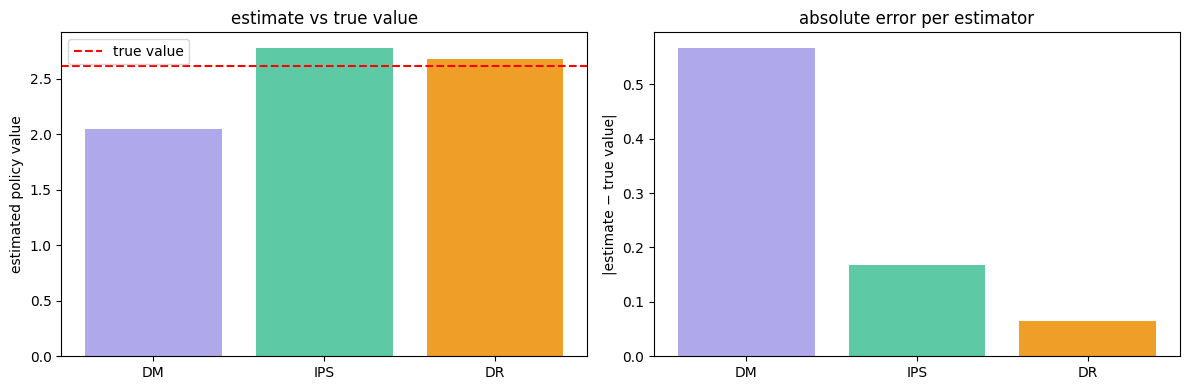

In [33]:
print("=" * 40)
print(f"true value:    {true_value:.4f}  ← ground truth")
print(f"DM estimate:   {dm_estimate:.4f}  error: {abs(dm_estimate - true_value):.4f}")
print(f"IPS estimate:  {ips_estimate:.4f}  error: {abs(ips_estimate - true_value):.4f}")
print(f"DR estimate:   {dr_estimate:.4f}  error: {abs(dr_estimate - true_value):.4f}")
print("=" * 40)

methods = ['DM', 'IPS', 'DR']
errors = [
    abs(dm_estimate  - true_value),
    abs(ips_estimate - true_value),
    abs(dr_estimate  - true_value),
]
estimates = [dm_estimate, ips_estimate, dr_estimate]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(methods, estimates, color=['#AFA9EC', '#5DCAA5', '#EF9F27'])
axes[0].axhline(true_value, color='red', linestyle='--', label='true value')
axes[0].set_title('estimate vs true value')
axes[0].set_ylabel('estimated policy value')
axes[0].legend()

axes[1].bar(methods, errors, color=['#AFA9EC', '#5DCAA5', '#EF9F27'])
axes[1].set_title('absolute error per estimator')
axes[1].set_ylabel('|estimate − true value|')

plt.tight_layout()
plt.show()

DM is worst because a linear regression model is too simple to capture your reward table — it's fitting a straight line through what's essentially a lookup table with non-linear structure, so the predictions are systematically biased. The error isn't noise — it's the model being genuinely wrong about the reward function.


IPS is surprisingly good here because your behavior and eval policies aren't that far apart — the biggest divergence is on push (0.1 behavior vs 0.8 eval for lapsed 30d), giving an importance weight of 8. That's high but not catastrophic with 10k samples to average over.



DR beats both because even though the reward model is bad, the IPS correction term catches and partially fixes those model errors. That's exactly the "doubly robust" guarantee — unbiased if either component is correct, and here the IPS component is close enough to pull the estimate toward truth even though DM alone was way off.

After changing the policy:

DM stayed roughly the same (0.52 → 0.57). Makes sense — DM doesn't use propensity scores at all, so changing the behavior policy barely affects it. The reward model is just as bad as before.


IPS got much worse (0.009 → 0.169). This is the distributional shift exploding. Your eval policy is email-heavy (0.7 email for lapsed_7d) but your new behavior policy almost never sends email (0.02). So whenever email appears in the logs, the importance weight is 0.7/0.02 = 35.

DR held up much better (0.005 → 0.066). Still degraded compared to before, but way less than IPS. The reward model is partially absorbing the variance that IPS can't handle — that's the doubly robust guarantee working in practice.